In [1]:
from matplotlib import pyplot as plt
import os
import numpy as np
import torch
from PIL import Image
from torchvision import utils, transforms

from model import Encoder, Generator

In [2]:
def image2tensor(image):
    img = torch.from_numpy(np.array(image)).to(torch.float32).div(255).add_(-0.5).mul_(2).permute(2, 0, 1)
    return img

def tensor2image(tensor):
    tensor = tensor.clamp_(-1., 1.).detach().squeeze().permute(1, 2, 0).mul(0.5).add_(0.5).cpu().numpy()
    return (tensor*255).astype(np.uint8)

## define model

In [3]:
swapEn_ckpt = "checkpoint/model42/150000.pt"

ckpt = torch.load(swapEn_ckpt, map_location=lambda storage, loc: storage)
ckpt_args = ckpt["args"]
imgsize = ckpt_args.size

enc = Encoder(ckpt_args.channel)
gen = Generator(ckpt_args.channel)
enc.load_state_dict(ckpt["e_ema"])
gen.load_state_dict(ckpt["g_ema"])
enc.eval()
gen.eval()

torch.set_grad_enabled(False)

## encode structure & texture

In [4]:
input_folder_path = "input_images/paper_further_trans"
output_folder_path = "result_codes/paper_further_trans"

#---make save dir---
stu_out_path = os.path.join(output_folder_path, "stu")
tx_out_path = os.path.join(output_folder_path, "tx")
if not os.path.exists(stu_out_path):
    os.makedirs(stu_out_path)
if not os.path.exists(tx_out_path):
    os.makedirs(tx_out_path)

ckpt = torch.load(swapEn_ckpt, map_location=lambda storage, loc: storage)
ckpt_args = ckpt["args"]
imgsize = ckpt_args.size
    
enc = Encoder(ckpt_args.channel)
gen = Generator(ckpt_args.channel)
enc.load_state_dict(ckpt["e_ema"])
gen.load_state_dict(ckpt["g_ema"])
enc.eval()
gen.eval()

# --- encode ---
torch.set_grad_enabled(False)

for filename in os.listdir(input_folder_path):
    img = Image.open(os.path.join(input_folder_path, filename))
    img_r = img.convert("RGB").resize((imgsize, imgsize))
    img_t = image2tensor(img_r).unsqueeze(0)
    stu, tx = enc(img_t)
    # ===SAVE CODE===
    name = os.path.splitext(filename)[0]
    np.save(os.path.join(stu_out_path, name + "_stu.npy"), stu)
    np.save(os.path.join(tx_out_path, name + "_tx.npy"), tx)

## mean style test

original transfer result


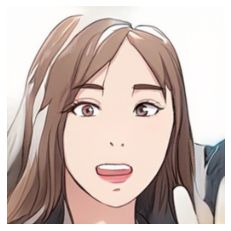

transfer rate = 0.6 result


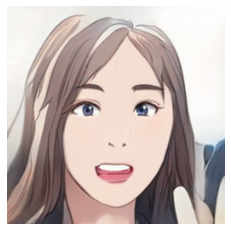

In [5]:
imgSavePath = "result"  # folder name

# ---get content img---
content_code_path = "result_codes/content_img"  # parent folder of \stu and \tx
contentName = "20"
struct = torch.from_numpy(np.load(os.path.join(content_code_path, "stu/" + contentName + "_stu.npy")))
texture = torch.from_numpy(np.load(os.path.join(content_code_path, "tx/" + contentName + "_tx.npy")))

# ---load style code---
swapStyleName = "ALL"
mean_style = torch.from_numpy(np.load("mean_style.npy"))

# ---swap68---
print("original transfer result")
swap68 = gen(struct, texture, mean_style, 6, 8)
swap68 = tensor2image(swap68)
plt.imshow(swap68)
plt.axis('off')
plt.show()

# ---transfer texture rate---
tx_style_rate = 0.6
tx_ori_rate = 1 - tx_style_rate
new_tx = (texture * tx_ori_rate) + (mean_style * tx_style_rate)

# ---generate---
transfer_img = gen(struct, texture, new_tx, 6, 8)

# ---show---
print(f"transfer rate = {tx_style_rate} result")
result = tensor2image(transfer_img)
plt.imshow(result)
plt.axis('off')
plt.show()

# ===SAVE IMG===
if not os.path.exists(imgSavePath):
    os.makedirs(imgSavePath)
transferImg_name = os.path.join(imgSavePath, f"{contentName}_{swapStyleName}_{tx_style_rate}.png")
utils.save_image(transfer_img, transferImg_name, nrow=1, normalize=True, range=(-1, 1))

# m34_R3, m42_R1, m42_R3 result
## import and define

In [5]:
from matplotlib import pyplot as plt
import os
import numpy as np
import torch
from PIL import Image
from torchvision import utils, transforms

from model import Encoder, Generator

def image2tensor(image):
    img = torch.from_numpy(np.array(image)).to(torch.float32).div(255).add_(-0.5).mul_(2).permute(2, 0, 1)
    return img

def tensor2image(tensor):
    tensor = tensor.clamp_(-1., 1.).detach().squeeze().permute(1, 2, 0).mul(0.5).add_(0.5).cpu().numpy()
    return (tensor*255).astype(np.uint8)

## define 3 models

In [6]:
swapEn_ckpt_base = "checkpoint/swap-en_webtoon_990000.pt"
swapEn_ckpt_m34 = "checkpoint/model34_150000.pt"
swapEn_ckpt_m42 = "checkpoint/model42_150000.pt"

ckpt_base = torch.load(swapEn_ckpt_base, map_location=lambda storage, loc: storage)
ckpt_args_base = ckpt_base["args"]
ckpt_m34 = torch.load(swapEn_ckpt_m34, map_location=lambda storage, loc: storage)
ckpt_args_m34 = ckpt_m34["args"]
ckpt_m42 = torch.load(swapEn_ckpt_m42, map_location=lambda storage, loc: storage)
ckpt_args_m42 = ckpt_m42["args"]
imgsize = ckpt_args_base.size

enc_b = Encoder(ckpt_args_base.channel)
gen_b = Generator(ckpt_args_base.channel)
enc_b.load_state_dict(ckpt_base["e_ema"])
gen_b.load_state_dict(ckpt_base["g_ema"])
enc_b.eval()
gen_b.eval()

enc_m34 = Encoder(ckpt_args_m34.channel)
gen_m34 = Generator(ckpt_args_m34.channel)
enc_m34.load_state_dict(ckpt_m34["e_ema"])
gen_m34.load_state_dict(ckpt_m34["g_ema"])
enc_m34.eval()
gen_m34.eval()

enc_m42 = Encoder(ckpt_args_m42.channel)
gen_m42 = Generator(ckpt_args_m42.channel)
enc_m42.load_state_dict(ckpt_m42["e_ema"])
gen_m42.load_state_dict(ckpt_m42["g_ema"])
enc_m42.eval()
gen_m42.eval()

torch.set_grad_enabled(False)

## define style
encode image

In [36]:
# ===== structure =====
# content_folder = 'human_cartoon'
content_folder_name = 'other_cartoon/styleflow'
content_name = 'g_0'
img_content = './input_images/' + content_folder_name + '/' + content_name + '.jpeg'

img = Image.open(img_content)
img_r = img.convert("RGB").resize((imgsize, imgsize))
img_t = image2tensor(img_r).unsqueeze(0)

stu_b, tx_b = enc_b(img_t)
stu_m34, tx_m34 = enc_m34(img_t)
stu_m42, tx_m42 = enc_m42(img_t)

# ===== style =====
# ---mean style---
# style_name = 'mean'
# mean_style = torch.from_numpy(np.load("mean_style.npy"))
# style_tx_m34 = mean_style
# style_tx_m42 = mean_style

# ---other styles---
style_folder_name = 'training_styles_test'
style_name = '2002'
img_style = './input_images/' + style_folder_name + '/' + style_name + '.png'

img = Image.open(img_style)
img_r = img.convert("RGB").resize((imgsize, imgsize))
img_t = image2tensor(img_r).unsqueeze(0)

_, style_tx_m34 = enc_m34(img_t)
_, style_tx_m42 = enc_m42(img_t)

generate results

original transfer result (model34_R3)


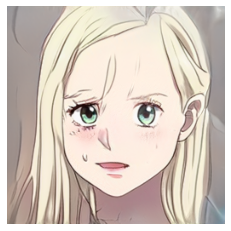

original transfer result (model42_R1)


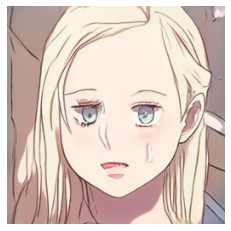

original transfer result (model42_R3)


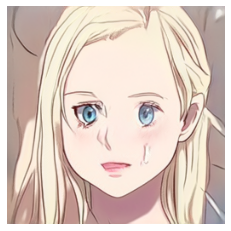

transfer rate = 0.8 result (model34_R3)


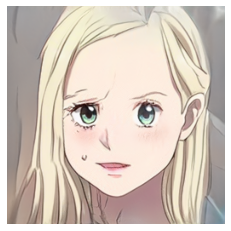

transfer rate = 0.8 result (model42_R1)


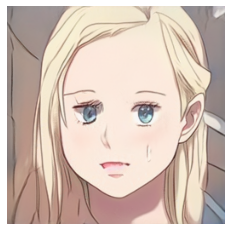

transfer rate = 0.8 result (model42_R3)


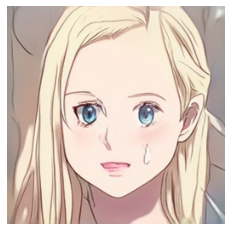

In [37]:
# ===== original result =====
# ---m34_R3---
print("original transfer result (model34_R3)")
m34_R3 = gen_m34(stu_b, tx_b, style_tx_m34, 6, 8)
result = tensor2image(m34_R3)
plt.imshow(result)
plt.axis('off')
plt.show()

# ---m42_R1---
print("original transfer result (model42_R1)")
m42_R1 = gen_m42(stu_m42, tx_m42, style_tx_m42, 6, 8)
result = tensor2image(m42_R1)
plt.imshow(result)
plt.axis('off')
plt.show()

# ---m42_R3---
print("original transfer result (model42_R3)")
m42_R3 = gen_m42(stu_b, tx_b, style_tx_m42, 6, 8)
result = tensor2image(m42_R3)
plt.imshow(result)
plt.axis('off')
plt.show()

# ===== transfer texture rate =====
tx_style_rate = 0.8
tx_ori_rate = 1 - tx_style_rate
new_tx_m34_R3 = (tx_b * tx_ori_rate) + (style_tx_m34 * tx_style_rate)
new_tx_m42_R1 = (tx_m42 * tx_ori_rate) + (style_tx_m42 * tx_style_rate)
new_tx_m42_R3 = (tx_b * tx_ori_rate) + (style_tx_m42 * tx_style_rate)

# ===== generate transfered result =====
new_m34_R3 = gen_m34(stu_b, tx_b, new_tx_m34_R3, 6, 8)
new_m42_R1 = gen_m42(stu_m42, tx_m42, new_tx_m42_R1, 6, 8)
new_m42_R3 = gen_m42(stu_b, tx_b, new_tx_m42_R3, 6, 8)

# ===== show =====
# ---m34_R3---
print(f"transfer rate = {tx_style_rate} result (model34_R3)")
result = tensor2image(new_m34_R3)
plt.imshow(result)
plt.axis('off')
plt.show()

# ---m42_R1---
print(f"transfer rate = {tx_style_rate} result (model42_R1)")
result = tensor2image(new_m42_R1)
plt.imshow(result)
plt.axis('off')
plt.show()

# ---m42_R3---
print(f"transfer rate = {tx_style_rate} result (model42_R3)")
result = tensor2image(new_m42_R3)
plt.imshow(result)
plt.axis('off')
plt.show()

save result

In [75]:
model_name = '34'
# model_name = '42'
# result_name = 'R1'
result_name = 'R3'

# ===== SAVE =====
imgSavePath = 'result/m' + model_name + '_' + result_name
if not os.path.exists(imgSavePath):
    os.makedirs(imgSavePath)

if model_name == '34':
    save_pic = m34_R3
else:
    if result_name == 'R1':
        save_pic = m42_R1
    else:
        save_pic = m42_R3

pic_name = 'm' + model_name + '_' + result_name + '_' + content_name + '_' + style_name + '.png'
save_name = os.path.join(imgSavePath, pic_name)
utils.save_image(save_pic, save_name, nrow=1, normalize=True, range=(-1, 1))

## 2 texture interpolation
load image code (m34/m42, R1/R3)

In [3]:
# model_name = '34'
model_name = '42'

# result_name = 'R1'
result_name = 'R3'

#=====================================================================

code_path = 'result_codes/model' + model_name + '_150k/'
tx_path = code_path + 'training_styles_test/'
if result_name == 'R1':
    stu_path = code_path + 'test_cartoon/'  # R1
else:
    stu_path = 'result_codes/webtoon/test_cartoon/'  # R3

tx1_name = '1604'
tx2_name = '341'
tx_1 = torch.from_numpy(np.load(tx_path + 'tx/' + tx1_name + '_tx.npy'))
tx_2 = torch.from_numpy(np.load(tx_path + 'tx/' + tx2_name + '_tx.npy'))

stu_name = '01'
stu = torch.from_numpy(np.load(stu_path + 'stu/' + stu_name + '_stu.npy'))
tx = torch.from_numpy(np.load(stu_path + 'tx/' + stu_name + '_tx.npy'))

generate imgs

In [4]:
imgSavePath = 'result/m' + model_name + '_' + result_name
sub_folder_name = tx1_name + '_' + tx2_name
imgSavePath = os.path.join(imgSavePath, sub_folder_name)
if not os.path.exists(imgSavePath):
    os.makedirs(imgSavePath)

for i in range(11):
    # ---transfer texture---
    rate = i * 0.1
    rate_2 = 1 - rate
    new_tx = (tx_1 * rate_2) + (tx_2 * rate)

    # ---swap---
    if model_name == '34':
        transfer_img = gen_m34(stu, tx, new_tx, 6, 8)  # m34
    else:
        transfer_img = gen_m42(stu, tx, new_tx, 6, 8)  # m42

    # =====SAVE IMG=====
    if i == 10:
        transferImg_name = os.path.join(imgSavePath, stu_name + '_' + tx1_name + '_' + tx2_name + '_1.0.png')
    else:
        transferImg_name = os.path.join(imgSavePath, stu_name + '_' + tx1_name + '_' + tx2_name + '_0.' + str(i) + '.png')
    utils.save_image(transfer_img, transferImg_name, nrow=1, normalize=True, range=(-1, 1))

## 2 structure interpolation
load image code (m34/m42, R1/R3)

In [19]:
# model_name = '34'
model_name = '42'

# result_name = 'R1'
result_name = 'R3'

#=====================================================================

code_path = 'result_codes/model' + model_name + '_150k/'
tx_path = code_path + 'training_styles_test/'
if result_name == 'R1':
    stu_path = code_path + 'test_cartoon/'  # R1
else:
    stu_path = 'result_codes/webtoon/test_cartoon/'  # R3

tx_name = '157'
tx = torch.from_numpy(np.load(tx_path + 'tx/' + tx_name + '_tx.npy'))

stu1_name = '08'
stu2_name = '09'
stu_1 = torch.from_numpy(np.load(stu_path + 'stu/' + stu1_name + '_stu.npy'))
stu_2 = torch.from_numpy(np.load(stu_path + 'stu/' + stu2_name + '_stu.npy'))
stu_tx_1 = torch.from_numpy(np.load(stu_path + 'tx/' + stu1_name + '_tx.npy'))
stu_tx_2 = torch.from_numpy(np.load(stu_path + 'tx/' + stu2_name + '_tx.npy'))

generate imgs

In [20]:
imgSavePath = 'result/m' + model_name + '_' + result_name
sub_folder_name = stu1_name + '_' + stu2_name
imgSavePath = os.path.join(imgSavePath, sub_folder_name)
if not os.path.exists(imgSavePath):
    os.makedirs(imgSavePath)

for i in range(11):
    # ---transfer texture---
    rate = i * 0.1
    rate_2 = 1 - rate
    new_stu = (stu_1 * rate_2) + (stu_2 * rate)
    new_stu_tx = (stu_tx_1 * rate_2) + (stu_tx_2 * rate)

    # ---swap---
    if model_name == '34':
        transfer_img = gen_m34(new_stu, new_stu_tx, tx, 6, 8)  # m34
    else:
        transfer_img = gen_m42(new_stu, new_stu_tx, tx, 6, 8)  # m42

    # =====SAVE IMG=====
    if i == 10:
        transferImg_name = os.path.join(imgSavePath, stu1_name + '_' + stu2_name + '_' + tx_name + '_1.0.png')
    else:
        transferImg_name = os.path.join(imgSavePath, stu1_name + '_' + stu2_name + '_' + tx_name + '_0.' + str(i) + '.png')
    utils.save_image(transfer_img, transferImg_name, nrow=1, normalize=True, range=(-1, 1))